In [6]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('../2.分类/Dataset/4.train.csv')
test = pd.read_csv('../2.分类/Dataset/4.test.csv')

print(train.head())
print(train.info())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [7]:
X = train.drop(['Id', 'SalePrice'], axis=1)
y = train['SalePrice']
X_test = test.drop('Id', axis=1)

numeric_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['object','str','string']).columns

X[numeric_features] = X[numeric_features].fillna(X[numeric_features].mean())
X[categorical_features] = X[categorical_features].fillna('missing')
X_test[numeric_features] = X_test[numeric_features].fillna(X_test[numeric_features].mean())
X_test[categorical_features] = X_test[categorical_features].fillna('missing')

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor())
])

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print(f'RMSE:{rmse:.2f}, R2:{r2:.2f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3236
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 193
[LightGBM] [Info] Start training from score 181441.541952
RMSE:29310.89, R2:0.89


In [11]:
param_grid = {
    'regressor__num_leaves': [31, 61, 91],
    'regressor__learning_rate': [0.05, 0.1, 0.2],
    'regressor__n_estimators': [100, 200, 500]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)

y_pred_best = grid_search.predict(X_val)

rmse_best = np.sqrt(mean_squared_error(y_val, y_pred_best))
r2_best = r2_score(y_val, y_pred_best)

print(f'Optimized RMSE: {rmse_best}')
print(f'Optimized R^2: {r2_best}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002293 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3236
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 193
[LightGBM] [Info] Start training from score 181441.541952
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

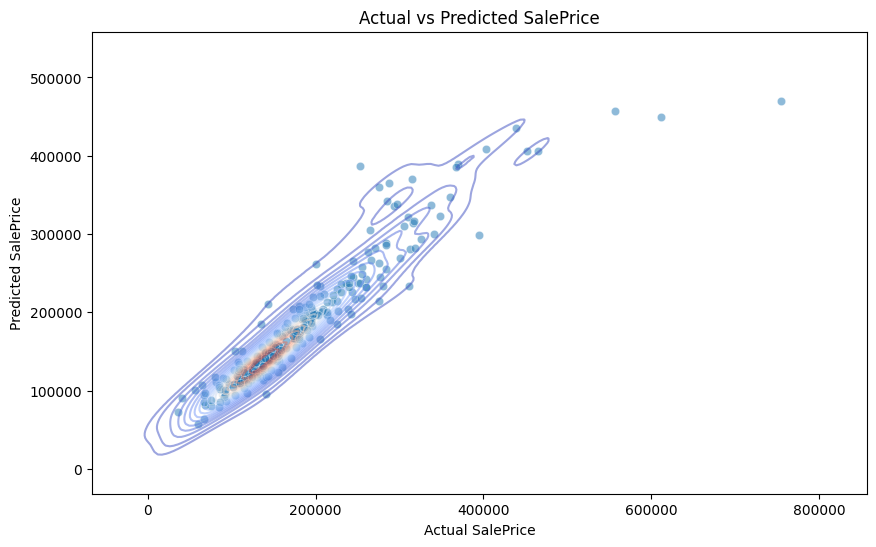

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_pred_best, alpha=0.5)
sns.kdeplot(x=y_val, y=y_pred_best, cmap='coolwarm', alpha=0.5, levels=20)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice")
plt.show()

In [20]:
feature_importances = grid_search.best_estimator_.named_steps["regressor"].feature_importances_
feature_importances

array([ 56, 124, 334, 137, 142, 201, 168,  96, 253,   5, 154, 234, 187,
        87,   0, 417,  39,   1,  22,  11,  31,   4,  35,  66, 137,  54,
       231,  80, 128,   7,   0,  18,   0,   0,  66,  62,   0,   7,   0,
        12,  14,   0,   0,   0,   0,   2,  12,   0,   0,  23,   5,   8,
         0,   4,   0,   0,   2,   5,   2,   0,  10,   1,   0,   0,   0,
         0,   0,  10,   0,   2,  20,   6,   1,   0,   0,   0,  11,   0,
         0,  12,   4,   7,   0,   1,   0,   3,   4,   0,   0,  15,   3,
        16,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   5,   0,   0,   2,   0,   6,   0,   0,   4,
         0,   3,   0,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,  13,   0,   0,   5,   0,   4,   2,   0,
         3,   5,   3,   0,   0,   0,   0,   0,   0,   0,   3,   0,   0,
         0,   2,   0,   0,   0,   2,   0,   0,  12,   7,   0,   7,   0,
         8,   5,   0,   0,   2,   0,   4,   1,  14,   3,   0,   

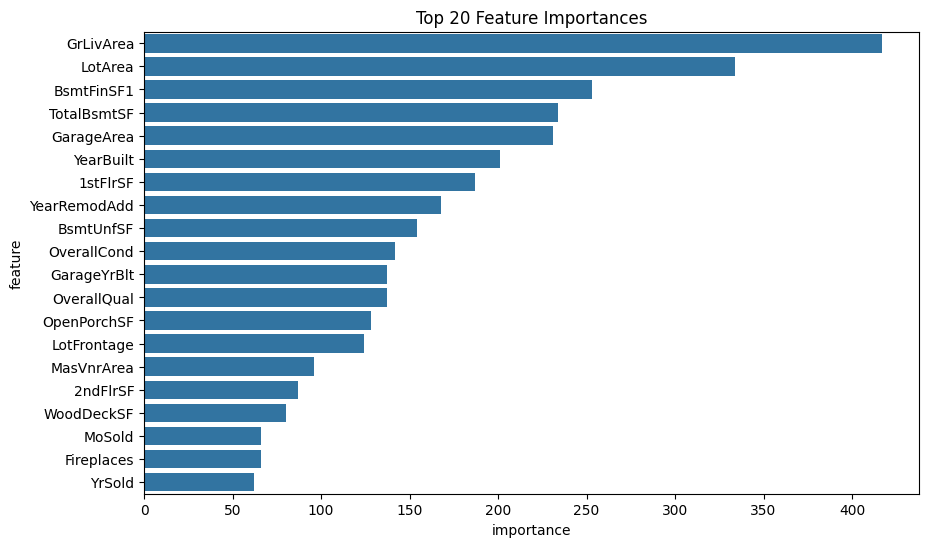

In [21]:
feature_names = numeric_features.to_list() + list(grid_search.best_estimator_.named_steps["preprocessor"].transformers_[1][1].named_steps["onehot"].get_feature_names_out(categorical_features))
feature_importances_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importances_df = feature_importances_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances_df, x='importance', y='feature')
plt.title('Top 20 Feature Importances')
plt.show()

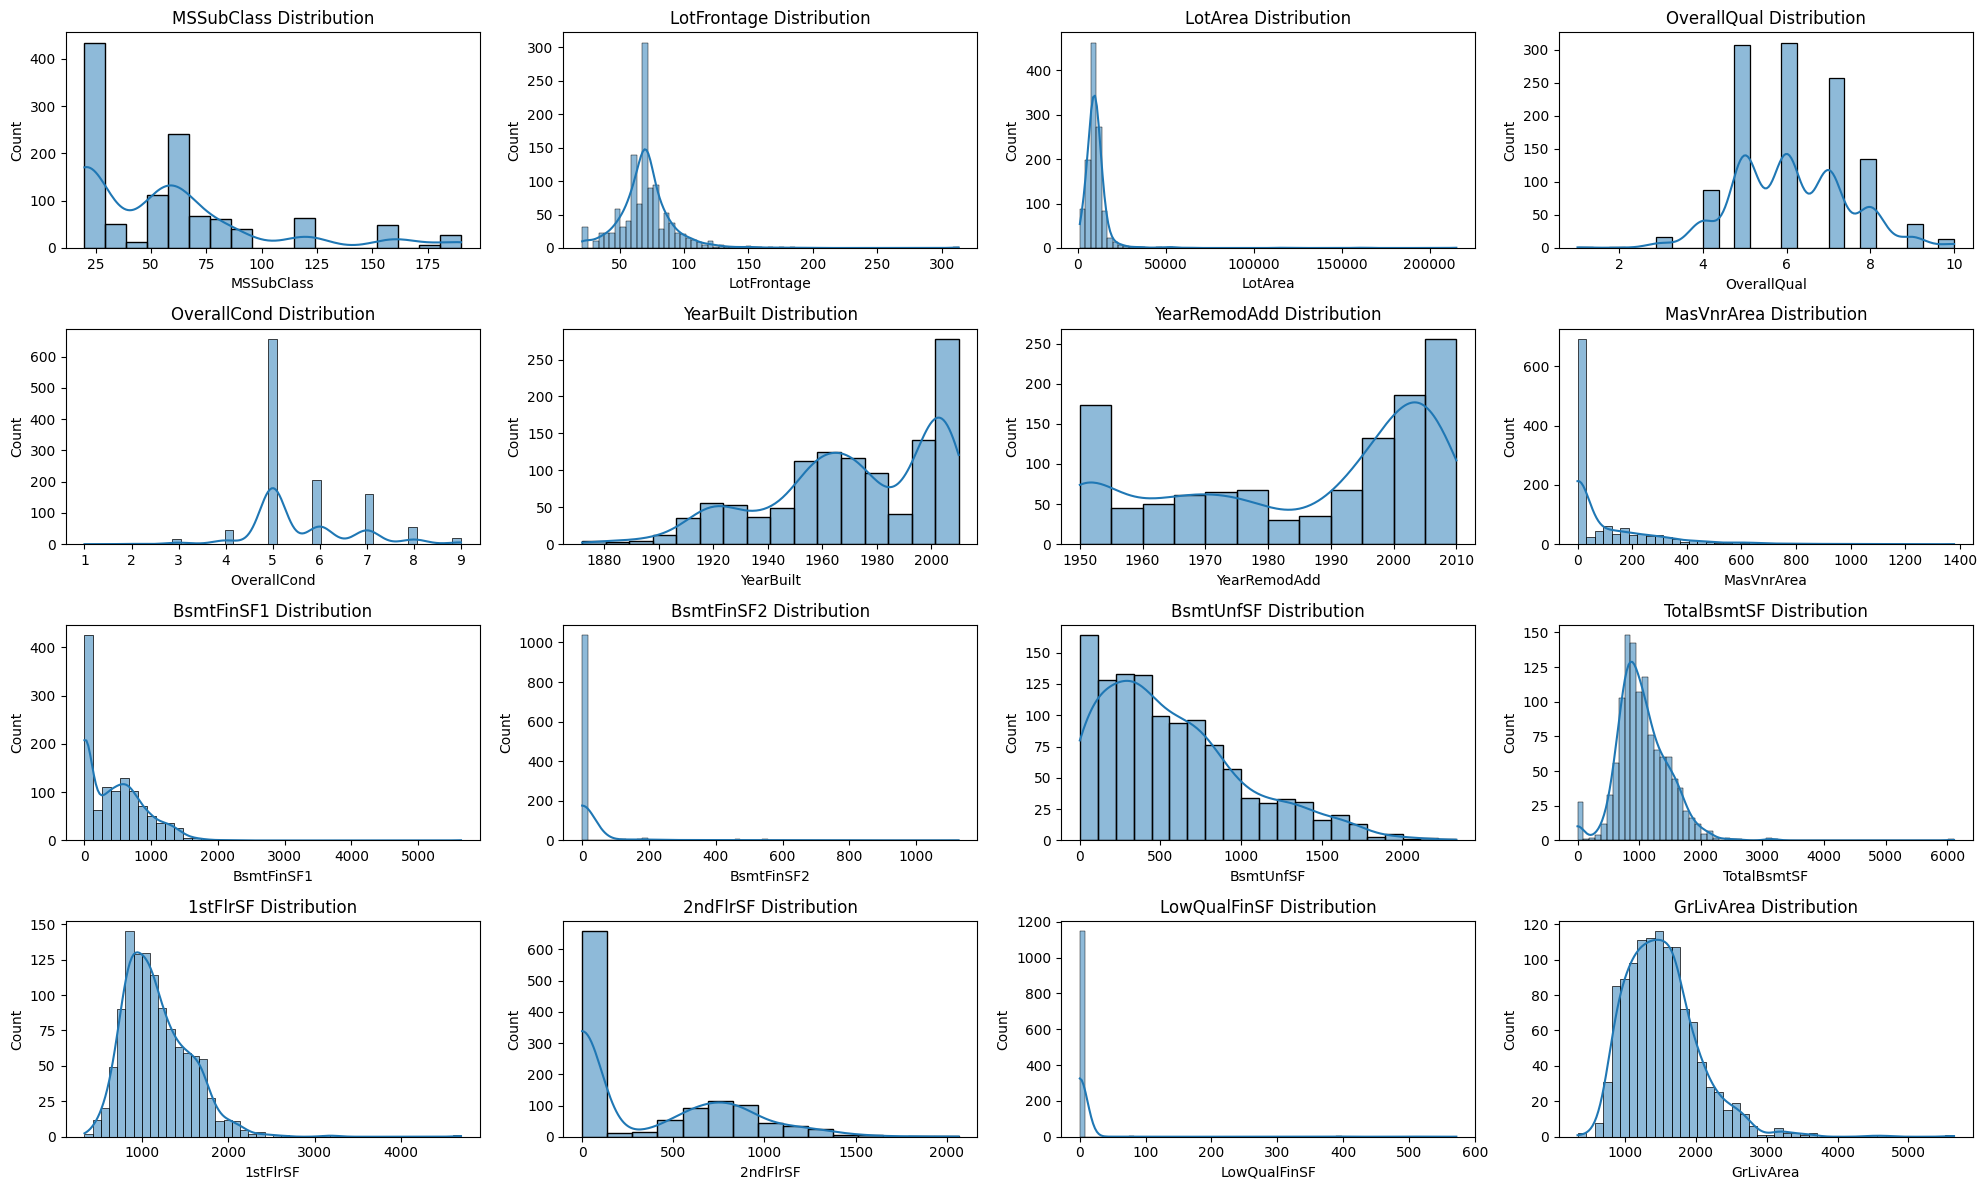

In [16]:
def visualize_distribution(data, features):
    plt.figure(figsize=(20, 12))
    for i,feature in enumerate(features):
        plt.subplot(4, 4, i+1)
        sns.histplot(data[feature], kde=True)
        plt.title(f'{feature} Distribution')
    plt.tight_layout()
    plt.show()

numeric_features_sample = numeric_features[:16]
visualize_distribution(X_train, numeric_features_sample)

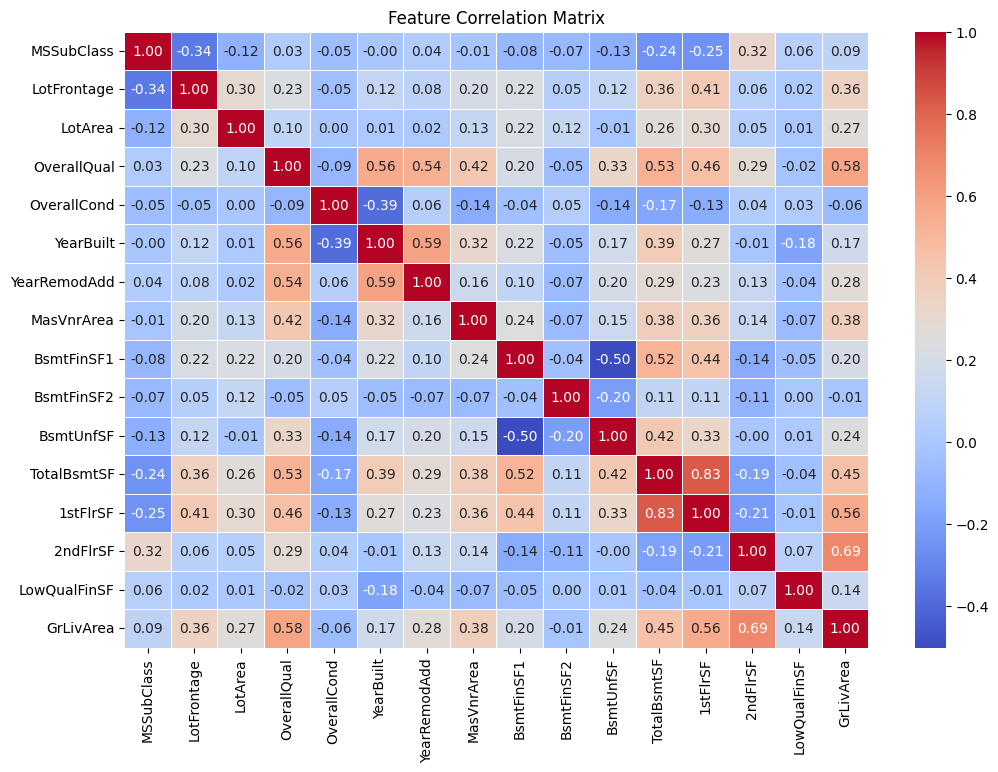

In [19]:
def visualize_correlation(data, features):
    correlation_matrix = data[features].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title("Feature Correlation Matrix")
    plt.show()

visualize_correlation(X_train, numeric_features[:16])

模型分析

LightGBM的优点

1. 高效性：LightGBM的训练速度快，适用于处理大规模数据。

2. 准确性：LightGBM在预测准确性方面通常表现良好。

3. 低内存占用：LightGBM在内存占用方面相对较低，能够处理大规模数据而不会导致内存溢出问题。

4. 自动处理缺失值：LightGBM能够自动处理缺失值，简化了数据预处理的流程。

LightGBM的缺点

1. 容易过拟合：与其他树模型类似，LightGBM容易过拟合，需要进行适当的正则化。

2. 对超参数敏感：LightGBM的性能受超参数的影响较大，需要进行仔细调参。

3. 不适用于小样本数据：LightGBM在小样本数据上可能表现不佳，需要足够的数据量才能发挥其优势。